In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Model import
import lightgbm as lgb

# Set plot style
sns.set_style("whitegrid")
print("--- All libraries imported successfully ---")

--- All libraries imported successfully ---


In [2]:
file_path = "../Data/disease_diagnosis.csv"
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully from '{file_path}'.")
print("Original shape:", df.shape)

# 1. Split Blood Pressure column
if "Blood_Pressure_mmHg" in df.columns:
    bp_split = df["Blood_Pressure_mmHg"].str.split("/", expand=True)
    df["Systolic_BP"] = pd.to_numeric(bp_split[0], errors="coerce")
    df["Diastolic_BP"] = pd.to_numeric(bp_split[1], errors="coerce")
    df.drop(columns=["Blood_Pressure_mmHg"], inplace=True)

print("\n--- Data Loading and Initial Cleaning Complete ---")
df.info()

Dataset loaded successfully from '../Data/disease_diagnosis.csv'.
Original shape: (2000, 13)

--- Data Loading and Initial Cleaning Complete ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Heart_Rate_bpm       2000 non-null   int64  
 4   Body_Temperature_C   2000 non-null   float64
 5   Oxygen_Saturation_%  2000 non-null   float64
 6   Symptom_1            2000 non-null   object 
 7   Symptom_2            1713 non-null   object 
 8   Symptom_3            1629 non-null   object 
 9   Severity             1580 non-null   object 
 10  Treatment_Plan       1580 non-null   object 
 11  Diagnosis            2000 non-null   object 
 12  Systolic_BP          2000 non-null   int64 

In [3]:
print("--- Starting Symptom Consolidation ---")

# 1. Consolidate the three symptom columns into a single list for each row
symptom_cols = ['Symptom_1', 'Symptom_2', 'Symptom_3']
df['All_Symptoms'] = df[symptom_cols].apply(
    lambda row: [symptom for symptom in row if pd.notna(symptom)], 
    axis=1
)

# 2. Use MultiLabelBinarizer to convert the list of symptoms into one-hot encoded columns
mlb = MultiLabelBinarizer()
symptom_encoded = mlb.fit_transform(df['All_Symptoms'])

# 3. Create a new DataFrame with these encoded features
symptom_df = pd.DataFrame(symptom_encoded, columns=mlb.classes_, index=df.index)

# 4. Concatenate the new symptom features back to the main DataFrame
df = pd.concat([df, symptom_df], axis=1)

# 5. Drop the original and intermediate symptom columns
df.drop(columns=symptom_cols + ['All_Symptoms'], inplace=True)

print(f"\nCreated {len(mlb.classes_)} new binary features from symptoms.")
print("The new symptom columns are:", mlb.classes_)
print("\n--- Symptom Consolidation Complete ---")
df.head()

--- Starting Symptom Consolidation ---

Created 8 new binary features from symptoms.
The new symptom columns are: ['Body ache' 'Cough' 'Fatigue' 'Fever' 'Headache' 'Runny nose'
 'Shortness of breath' 'Sore throat']

--- Symptom Consolidation Complete ---


,Patient_ID,Age,Gender,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%,Severity,Treatment_Plan,Diagnosis,Systolic_BP,Diastolic_BP,Body ache,Cough,Fatigue,Fever,Headache,Runny nose,Shortness of breath,Sore throat
0,1,67,Male,89,38.25,94.47,Moderate,Medication and rest,Flu,125,89,1,0,0,1,1,0,0,0
1,2,44,Female,86,36.52,99.06,Mild,Rest and fluids,Cold,115,95,0,0,0,0,1,0,0,1
2,3,61,Female,64,38.33,93.89,Severe,Hospitalization and medication,Bronchitis,133,82,0,0,0,0,0,1,0,1
3,4,67,Male,75,37.59,94.79,NaN,NaN,Healthy,112,75,0,0,0,0,0,1,0,0
4,5,49,Male,99,40.50,93.90,Severe,Hospitalization and medication,Pneumonia,162,86,0,0,1,1,0,0,1,0


In [4]:
# The target variable is 'Diagnosis'
y = df["Diagnosis"]

# The features are all columns except the patient ID and the other potential target variables
X = df.drop(columns=["Diagnosis", "Patient_ID", "Severity", "Treatment_Plan"])

print("\nShape of feature set (X):", X.shape)
print("Shape of target set (y):", y.shape)

print("\nFinal list of features being used for training:")
print(X.columns.tolist())


Shape of feature set (X): (2000, 15)
Shape of target set (y): (2000,)

Final list of features being used for training:
['Age', 'Gender', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP', 'Body ache', 'Cough', 'Fatigue', 'Fever', 'Headache', 'Runny nose', 'Shortness of breath', 'Sore throat']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Stratify ensures the class distribution is similar in train and test sets
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (1600, 15)
Testing set shape: (400, 15)


In [ ]:
print("--- Building the ColumnTransformer preprocessing pipeline ---")

# Identify numerical and categorical feature names from X
# Note: The new symptom columns are already binary (0/1) and don't need processing.
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

# The symptom columns (which are now numbers) will be caught by the numerical_features selector.
# We need to ensure they are NOT scaled, only imputed if necessary.
# Let's separate them explicitly.
symptom_features = mlb.classes_
numerical_features = [col for col in numerical_features if col not in symptom_features]


print("\nIdentified Numerical Features for Scaling/Imputing:")
print(numerical_features)
print("\nIdentified Categorical Features for OneHotEncoding:")
print(categorical_features)
print("\nIdentified Symptom Features (will be passed through):")
print(symptom_features)


# Create the preprocessing pipeline for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create the preprocessing pipeline for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Assemble the final preprocessor
# It will apply transformations to the identified columns and pass through the rest
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'  # This is crucial! It keeps the symptom columns untouched.
)

print("\n--- Preprocessing Pipeline Assembled ---")

--- Building the ColumnTransformer preprocessing pipeline ---

Identified Numerical Features for Scaling/Imputing:
['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']

Identified Categorical Features for OneHotEncoding:
['Gender']

Identified Symptom Features (will be passed through):
['Body ache' 'Cough' 'Fatigue' 'Fever' 'Headache' 'Runny nose'
 'Shortness of breath' 'Sore throat']

--- Preprocessing Pipeline Assembled ---


In [7]:

# Create the full pipeline by combining the preprocessor with the classifier
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(random_state=42))
])

print("--- Training the LightGBM model ---")

# Train the model on the training data
model_pipeline.fit(X_train, y_train)

print("--- Model training complete ---")

--- Training the LightGBM model ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001623 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 779
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 16
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.560648
[LightGBM] [Info] Start training from score -1.584745
[LightGBM] [Info] Start training from score -1.560648
[LightGBM] [Info] Start training from score -1.742969
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
--- Model training complete ---


--- Evaluating the model on the test set ---

Classification Report:

              precision    recall  f1-score   support

  Bronchitis       0.82      0.84      0.83        80
        Cold       0.87      0.87      0.87        84
         Flu       0.95      0.91      0.93        82
     Healthy       0.86      0.92      0.89        84
   Pneumonia       0.88      0.81      0.84        70

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400


Confusion Matrix:


e:\HealthCareProject\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


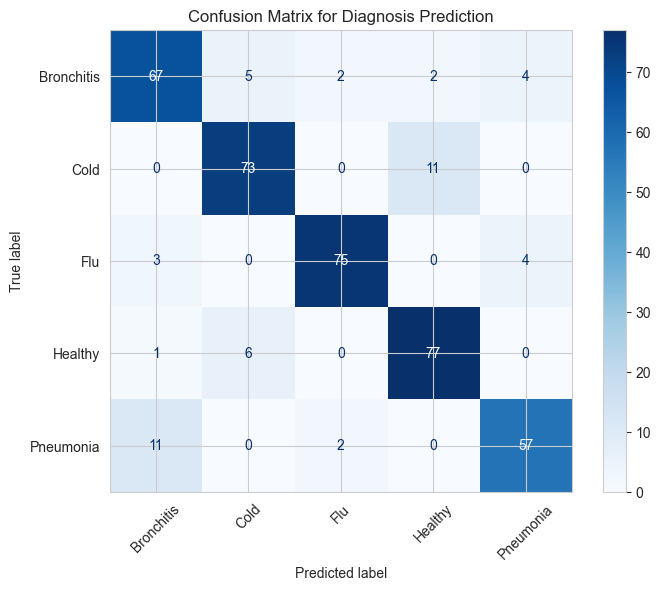

In [8]:
print("--- Evaluating the model on the test set ---")

# Make predictions on the test data
y_pred = model_pipeline.predict(X_test)

# --- Full Evaluation ---
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
# Ensure labels are consistent for the confusion matrix
labels = model_pipeline.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for Diagnosis Prediction")
plt.xticks(rotation=45)
plt.show()

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Model imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# Set plot style
sns.set_style("whitegrid")
print("--- All libraries imported successfully ---")

--- All libraries imported successfully ---


In [11]:
# --- Load your dataset ---
file_path = '../Data/disease_diagnosis.csv' # IMPORTANT: Replace with your actual file path
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully from '{file_path}'.")

# 1. Split Blood Pressure column
if "Blood_Pressure_mmHg" in df.columns:
    bp_split = df["Blood_Pressure_mmHg"].str.split("/", expand=True)
    df["Systolic_BP"] = pd.to_numeric(bp_split[0], errors="coerce")
    df["Diastolic_BP"] = pd.to_numeric(bp_split[1], errors="coerce")
    df.drop(columns=["Blood_Pressure_mmHg"], inplace=True)

print("\n--- Data Loading and Initial Cleaning Complete ---")

Dataset loaded successfully from '../Data/disease_diagnosis.csv'.

--- Data Loading and Initial Cleaning Complete ---


In [12]:
print("--- Starting Symptom Consolidation ---")
symptom_cols = ['Symptom_1', 'Symptom_2', 'Symptom_3']
df['All_Symptoms'] = df[symptom_cols].apply(lambda row: [s for s in row if pd.notna(s)], axis=1)
mlb = MultiLabelBinarizer()
symptom_encoded = mlb.fit_transform(df['All_Symptoms'])
symptom_df = pd.DataFrame(symptom_encoded, columns=mlb.classes_, index=df.index)
df = pd.concat([df, symptom_df], axis=1)
df.drop(columns=symptom_cols + ['All_Symptoms'], inplace=True)
print("--- Symptom Consolidation Complete ---")

--- Starting Symptom Consolidation ---
--- Symptom Consolidation Complete ---


In [13]:
y = df["Diagnosis"]
X = df.drop(columns=["Diagnosis", "Patient_ID", "Severity", "Treatment_Plan"])

In [14]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
symptom_features = mlb.classes_
numerical_features = [col for col in numerical_features if col not in symptom_features]

numerical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

In [15]:
# Define the models we want to compare
# We add class_weight='balanced' to each to handle the class imbalance.
models = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "LightGBM": lgb.LGBMClassifier(random_state=42, class_weight='balanced')
}

# Loop through each model to train and evaluate
for name, model in models.items():
    # Create the full pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    print(f"--- Training {name} ---")
    pipeline.fit(X_train, y_train)
    
    print(f"\n--- Evaluating {name} ---")
    y_pred = pipeline.predict(X_test)
    
    print(f"\nClassification Report for {name}:\n")
    print(classification_report(y_test, y_pred))
    print("-" * 50 + "\n")

--- Training Logistic Regression ---

--- Evaluating Logistic Regression ---

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

  Bronchitis       0.88      0.85      0.87        80
        Cold       0.92      0.90      0.91        84
         Flu       0.97      0.90      0.94        82
     Healthy       0.90      0.94      0.92        84
   Pneumonia       0.87      0.94      0.90        70

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400

--------------------------------------------------

--- Training Random Forest ---

--- Evaluating Random Forest ---

Classification Report for Random Forest:

              precision    recall  f1-score   support

  Bronchitis       0.85      0.85      0.85        80
        Cold       0.91      0.87      0.89        84
         Flu       0.96      0.90      0.93        82
     Hea

e:\HealthCareProject\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
# Cell 1: Imports & settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

sns.set_style("whitegrid")
RANDOM_STATE = 42
print("Libraries loaded.")


Libraries loaded.


In [17]:
# Cell 2: Load dataset (update path if needed) and basic cleaning
file_path = "../Data/disease_diagnosis.csv"   # <-- update if different
df = pd.read_csv(file_path)
print("Loaded:", file_path, "shape:", df.shape)

# Split Blood_Pressure_mmHg into numeric columns if present
if "Blood_Pressure_mmHg" in df.columns:
    bp_split = df["Blood_Pressure_mmHg"].astype(str).str.split("/", expand=True)
    df["Systolic_BP"] = pd.to_numeric(bp_split[0], errors="coerce")
    df["Diastolic_BP"] = pd.to_numeric(bp_split[1], errors="coerce")
    df.drop(columns=["Blood_Pressure_mmHg"], inplace=True)

df.info()


Loaded: ../Data/disease_diagnosis.csv shape: (2000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Heart_Rate_bpm       2000 non-null   int64  
 4   Body_Temperature_C   2000 non-null   float64
 5   Oxygen_Saturation_%  2000 non-null   float64
 6   Symptom_1            2000 non-null   object 
 7   Symptom_2            1713 non-null   object 
 8   Symptom_3            1629 non-null   object 
 9   Severity             1580 non-null   object 
 10  Treatment_Plan       1580 non-null   object 
 11  Diagnosis            2000 non-null   object 
 12  Systolic_BP          2000 non-null   int64  
 13  Diastolic_BP         2000 non-null   int64  
dtypes: float64(2), int64(5), object(

In [18]:
# Cell 3: Consolidate symptom columns into multi-hot representation
symptom_cols = ['Symptom_1', 'Symptom_2', 'Symptom_3']
df['All_Symptoms'] = df[symptom_cols].apply(lambda row: [s for s in row if pd.notna(s)], axis=1)
mlb = MultiLabelBinarizer()
symptom_encoded = mlb.fit_transform(df['All_Symptoms'])
symptom_df = pd.DataFrame(symptom_encoded, columns=mlb.classes_, index=df.index)
df = pd.concat([df, symptom_df], axis=1)
df.drop(columns=symptom_cols + ['All_Symptoms'], inplace=True)

print(f"Created {len(mlb.classes_)} symptom features.")
print("Example columns:", list(mlb.classes_)[:10])


Created 8 symptom features.
Example columns: ['Body ache', 'Cough', 'Fatigue', 'Fever', 'Headache', 'Runny nose', 'Shortness of breath', 'Sore throat']


In [19]:
# Cell 4: Define X, y and train/test split
y = df["Diagnosis"]
X = df.drop(columns=["Diagnosis", "Patient_ID", "Severity", "Treatment_Plan"], errors='ignore')

# List feature types
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
# Symptom features (binary) - they are numeric; keep them out of scaling if desired
symptom_cols_generated = list(mlb.classes_)
numeric_cols_no_symptoms = [c for c in numeric_cols if c not in symptom_cols_generated]

print("Numeric (no symptoms):", numeric_cols_no_symptoms)
print("Categorical:", categorical_cols)
print("Symptom columns (count):", len(symptom_cols_generated))

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Numeric (no symptoms): ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']
Categorical: ['Gender']
Symptom columns (count): 8
Train shape: (1600, 15) Test shape: (400, 15)


In [ ]:
# Cell 5: Preprocessors tailored to each model

# 1) Logistic Regression: scale numeric features, OHE categorical, pass symptoms untouched
preprocessor_lr = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols_no_symptoms),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols)
], remainder="passthrough")  # symptom columns passed through

# 2) Random Forest: impute numeric, do NOT scale (tree-based). OHE categorical, pass symptoms
preprocessor_rf = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols_no_symptoms),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols)
], remainder="passthrough")

# 3) LightGBM: LightGBM can accept numeric features; use imputer but avoid scaling. We will OHE categorical as well.
preprocessor_lgb = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols_no_symptoms),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=True))]), categorical_cols)
], remainder="passthrough")

print("Preprocessors defined.")


TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

In [21]:
# Cell 5: Preprocessors tailored to each model

# 1) Logistic Regression: scale numeric features, OHE categorical, pass symptoms untouched
preprocessor_lr = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols_no_symptoms),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_cols)
], remainder="passthrough")

# 2) Random Forest: impute numeric, do NOT scale (tree-based). OHE categorical, pass symptoms
preprocessor_rf = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), numeric_cols_no_symptoms),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_cols)
], remainder="passthrough")

# 3) LightGBM: impute numeric, OHE categorical (dense encoding), pass symptoms
preprocessor_lgb = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), numeric_cols_no_symptoms),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_cols)
], remainder="passthrough")

print("Preprocessors defined.")


Preprocessors defined.


In [22]:
# Cell 6: Model pipelines and hyperparameter grids
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
n_jobs = -1
scoring = "f1_weighted"

# Logistic Regression pipeline & grid
pipe_lr = Pipeline([("preprocessor", preprocessor_lr), ("clf", LogisticRegression(random_state=RANDOM_STATE, max_iter=2000, class_weight='balanced'))])
param_grid_lr = {
    "clf__C": [0.01, 0.1, 1.0, 5.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["saga"]  # saga supports multinomial with l2 and class_weight
}

# Random Forest pipeline & grid
pipe_rf = Pipeline([("preprocessor", preprocessor_rf), ("clf", RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))])
param_grid_rf = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 10, 25],
    "clf__min_samples_leaf": [1, 3, 6]
}

# LightGBM pipeline & grid
pipe_lgb = Pipeline([("preprocessor", preprocessor_lgb), ("clf", lgb.LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced'))])
param_grid_lgb = {
    "clf__num_leaves": [31, 63],
    "clf__n_estimators": [200, 400],
    "clf__learning_rate": [0.05, 0.1]
}

grids = {
    "LogisticRegression": (pipe_lr, param_grid_lr),
    "RandomForest": (pipe_rf, param_grid_rf),
    "LightGBM": (pipe_lgb, param_grid_lgb)
}
print("Pipelines and parameter grids ready.")


Pipelines and parameter grids ready.



=== Tuning and training: LogisticRegression ===
Fitting 4 folds for each of 4 candidates, totalling 16 fits
Best params for LogisticRegression: {'clf__C': 5.0, 'clf__penalty': 'l2', 'clf__solver': 'saga'}
Best CV f1_weighted: 0.9104560039833002

Classification Report for LogisticRegression (test set):

              precision    recall  f1-score   support

  Bronchitis       0.90      0.88      0.89        80
        Cold       0.92      0.93      0.92        84
         Flu       0.97      0.89      0.93        82
     Healthy       0.92      0.93      0.92        84
   Pneumonia       0.87      0.96      0.91        70

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.91       400
weighted avg       0.92      0.92      0.92       400



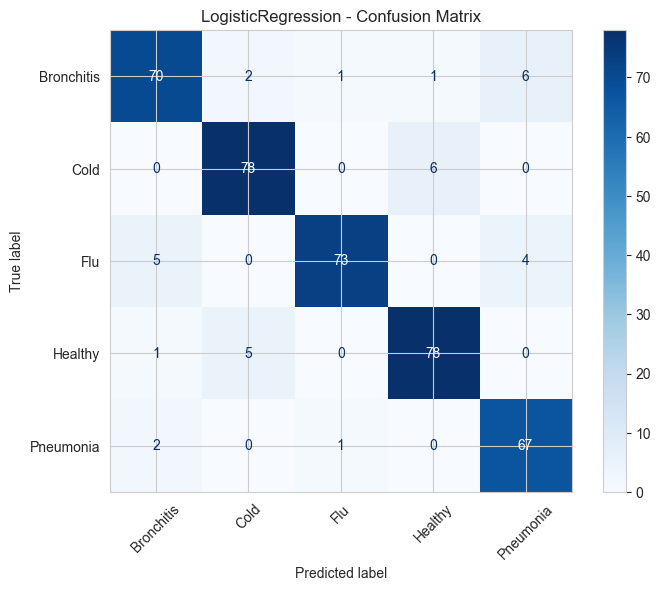

Saved best pipeline to best_pipeline_LogisticRegression.joblib

=== Tuning and training: RandomForest ===
Fitting 4 folds for each of 18 candidates, totalling 72 fits
Best params for RandomForest: {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}
Best CV f1_weighted: 0.8877787136537565

Classification Report for RandomForest (test set):

              precision    recall  f1-score   support

  Bronchitis       0.85      0.85      0.85        80
        Cold       0.89      0.81      0.85        84
         Flu       0.96      0.89      0.92        82
     Healthy       0.81      0.94      0.87        84
   Pneumonia       0.87      0.89      0.88        70

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



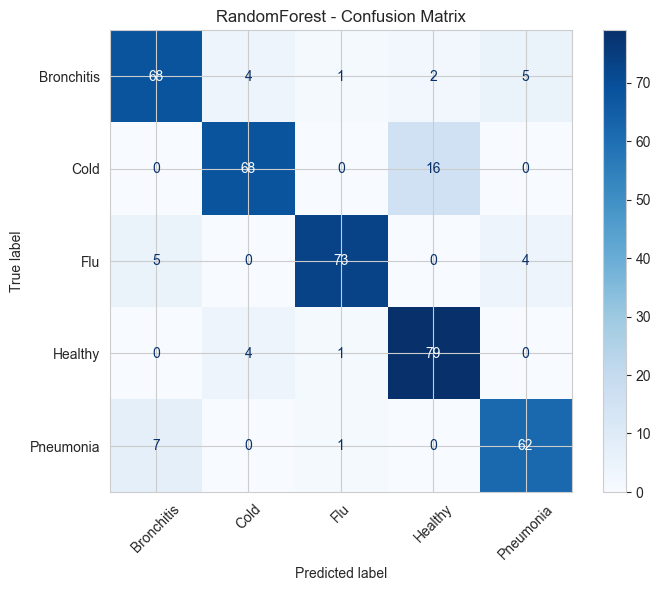

Saved best pipeline to best_pipeline_RandomForest.joblib

=== Tuning and training: LightGBM ===
Fitting 4 folds for each of 8 candidates, totalling 32 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 16
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

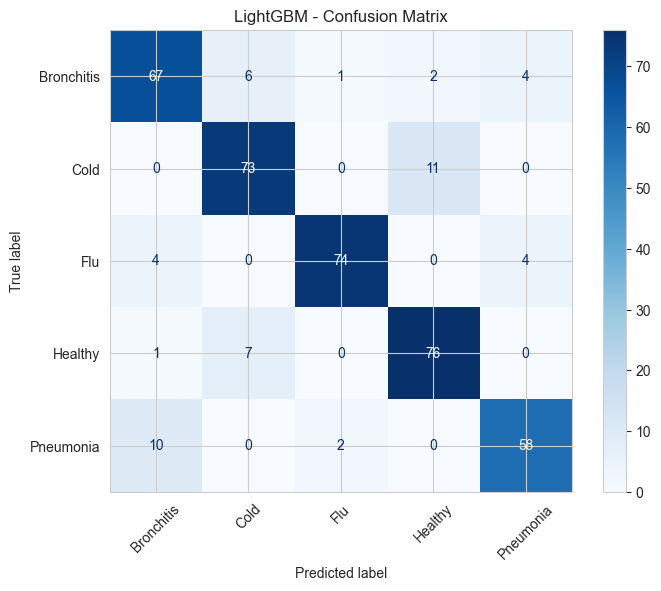

Saved best pipeline to best_pipeline_LightGBM.joblib


In [23]:
# Cell 7: Run GridSearchCV, evaluate, and save best pipelines
results = {}
for name, (pipeline, param_grid) in grids.items():
    print(f"\n=== Tuning and training: {name} ===")
    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        verbose=1
    )
    gs.fit(X_train, y_train)
    print(f"Best params for {name}:", gs.best_params_)
    print(f"Best CV {scoring}:", gs.best_score_)

    # Evaluate on test set
    best_pipeline = gs.best_estimator_
    y_pred = best_pipeline.predict(X_test)
    print(f"\nClassification Report for {name} (test set):\n")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix plot
    labels = best_pipeline.named_steps['clf'].classes_
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(8,6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f"{name} - Confusion Matrix")
    plt.xticks(rotation=45)
    plt.show()
    
    # Save results and model
    results[name] = {
        "grid_search": gs,
        "best_pipeline": best_pipeline,
        "test_report": classification_report(y_test, y_pred, output_dict=True)
    }
    joblib.dump(best_pipeline, f"best_pipeline_{name}.joblib")
    print(f"Saved best pipeline to best_pipeline_{name}.joblib")


In [24]:
# Cell 8: Quick summary table of test f1 (weighted) for each model
summary = []
for name, res in results.items():
    report_dict = res["test_report"]
    weighted_f1 = report_dict.get("weighted avg", {}).get("f1-score", None)
    accuracy = report_dict.get("accuracy", None)
    summary.append({"model": name, "weighted_f1": weighted_f1, "accuracy": accuracy})

summary_df = pd.DataFrame(summary).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
display(summary_df)


,model,weighted_f1,accuracy
0,LogisticRegression,0.915068,0.915
1,RandomForest,0.875146,0.875
2,LightGBM,0.870376,0.870


In [ ]:
# ---

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import lightgbm as lgb

sns.set_style("whitegrid")
print("✅ Libraries imported")


✅ Libraries imported


In [2]:
# Cell 2: Load and preprocess dataset
file_path = "../Data/disease_diagnosis.csv"
df = pd.read_csv(file_path)
print(f"✅ Dataset loaded: {df.shape}")

# Split blood pressure column
if "Blood_Pressure_mmHg" in df.columns:
    bp_split = df["Blood_Pressure_mmHg"].str.split("/", expand=True)
    df["Systolic_BP"] = pd.to_numeric(bp_split[0], errors="coerce")
    df["Diastolic_BP"] = pd.to_numeric(bp_split[1], errors="coerce")
    df.drop(columns=["Blood_Pressure_mmHg"], inplace=True)

# Consolidate symptoms
symptom_cols = ["Symptom_1", "Symptom_2", "Symptom_3"]
df["All_Symptoms"] = df[symptom_cols].apply(lambda r: [s for s in r if pd.notna(s)], axis=1)

mlb = MultiLabelBinarizer()
symptom_encoded = mlb.fit_transform(df["All_Symptoms"])
symptom_df = pd.DataFrame(symptom_encoded, columns=mlb.classes_, index=df.index)

df = pd.concat([df, symptom_df], axis=1)
df.drop(columns=symptom_cols + ["All_Symptoms"], inplace=True)

print("✅ Symptom encoding complete")


✅ Dataset loaded: (2000, 13)
✅ Symptom encoding complete


In [3]:
# Cell 3: Feature/target split
y = df["Diagnosis"]
X = df.drop(columns=["Diagnosis", "Patient_ID", "Severity", "Treatment_Plan"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()
symptom_features = mlb.classes_
numeric_cols_no_symptoms = [c for c in numeric_cols if c not in symptom_features]

print("Numeric cols:", numeric_cols_no_symptoms)
print("Categorical cols:", categorical_cols)
print("Symptom cols:", symptom_features)


Training set: (1600, 15), Test set: (400, 15)
Numeric cols: ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']
Categorical cols: ['Gender']
Symptom cols: ['Body ache' 'Cough' 'Fatigue' 'Fever' 'Headache' 'Runny nose'
 'Shortness of breath' 'Sore throat']


In [6]:
# Cell 4: Define preprocessors per model

# Logistic Regression → needs scaling
preprocessor_lr = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), numeric_cols_no_symptoms),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols)
], remainder="passthrough")

# Random Forest → no scaling
preprocessor_rf = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols_no_symptoms),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols)
], remainder="passthrough")

# LightGBM → no scaling
preprocessor_lgb = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols_no_symptoms),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_cols)
], remainder="passthrough")

# SVM → requires scaling
preprocessor_svm = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), numeric_cols_no_symptoms),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols)
], remainder="passthrough")

print("✅ Preprocessors defined")


✅ Preprocessors defined


In [7]:
# Cell 5: Define models + pipelines
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_lr),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_rf),
        ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42))
    ]),
    "LightGBM": Pipeline([
        ("preprocessor", preprocessor_lgb),
        ("classifier", lgb.LGBMClassifier(class_weight="balanced", random_state=42))
    ]),
    "SVM": Pipeline([
        ("preprocessor", preprocessor_svm),
        ("classifier", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ])
}

print("✅ Models and pipelines created")


✅ Models and pipelines created



🔹 Training Logistic Regression...

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

  Bronchitis       0.88      0.85      0.87        80
        Cold       0.92      0.90      0.91        84
         Flu       0.97      0.90      0.94        82
     Healthy       0.90      0.94      0.92        84
   Pneumonia       0.87      0.94      0.90        70

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



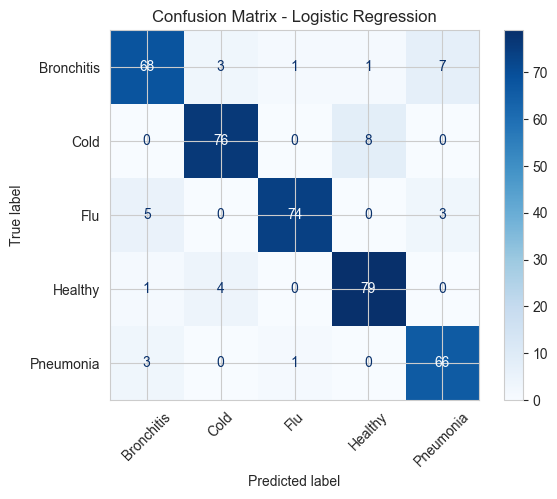


🔹 Training Random Forest...

Classification Report for Random Forest:

              precision    recall  f1-score   support

  Bronchitis       0.85      0.85      0.85        80
        Cold       0.90      0.87      0.88        84
         Flu       0.96      0.90      0.93        82
     Healthy       0.87      0.95      0.91        84
   Pneumonia       0.89      0.89      0.89        70

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



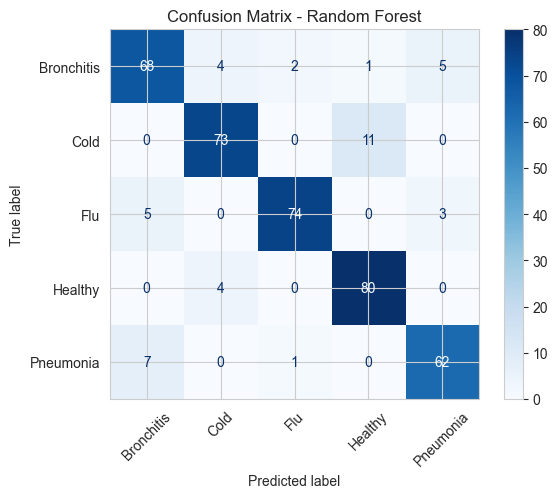


🔹 Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 16
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


e:\HealthCareProject\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Classification Report for LightGBM:

              precision    recall  f1-score   support

  Bronchitis       0.81      0.82      0.82        80
        Cold       0.85      0.85      0.85        84
         Flu       0.94      0.91      0.93        82
     Healthy       0.83      0.89      0.86        84
   Pneumonia       0.89      0.83      0.86        70

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



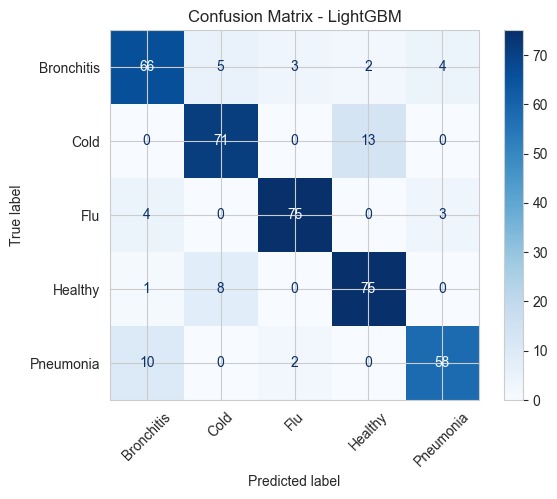


🔹 Training SVM...

Classification Report for SVM:

              precision    recall  f1-score   support

  Bronchitis       0.88      0.79      0.83        80
        Cold       0.92      0.86      0.89        84
         Flu       0.95      0.91      0.93        82
     Healthy       0.84      0.94      0.89        84
   Pneumonia       0.82      0.90      0.86        70

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



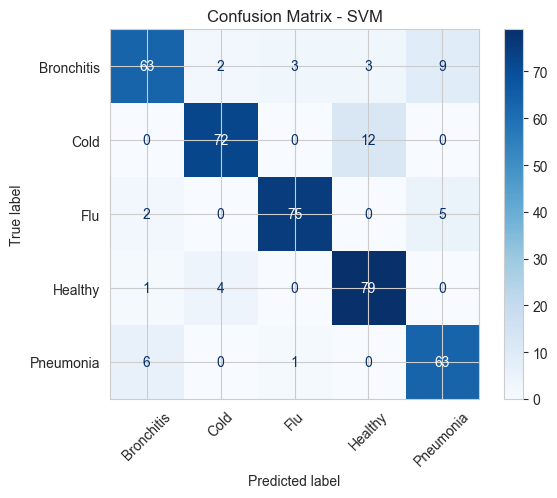

In [8]:
# Cell 6: Train and evaluate each model
for name, pipeline in models.items():
    print(f"\n🔹 Training {name}...")
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print(f"\nClassification Report for {name}:\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


In [9]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression hyperparameters
param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs", "saga"]
}

# Random Forest hyperparameters
param_grid_rf = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

# LightGBM hyperparameters
param_grid_lgb = {
    "classifier__num_leaves": [31, 50],
    "classifier__max_depth": [-1, 10, 20],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__n_estimators": [100, 200]
}

# SVM hyperparameters
param_grid_svm = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf"],
    "classifier__gamma": ["scale", "auto"]
}


In [10]:
# Example for Logistic Regression
pipeline_lr = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring="f1_macro", n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Best Params (LR):", grid_lr.best_params_)
print("Best Score (LR):", grid_lr.best_score_)


Best Params (LR): {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best Score (LR): 0.9099844351409665


In [11]:
# Logistic Regression
pipeline_lr = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring="f1_macro", n_jobs=-1)
grid_lr.fit(X_train, y_train)

# Random Forest
pipeline_rf = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42))
])
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring="f1_macro", n_jobs=-1)
grid_rf.fit(X_train, y_train)

# LightGBM
pipeline_lgb = Pipeline([
    ("preprocessor", preprocessor_lgb),
    ("classifier", lgb.LGBMClassifier(class_weight="balanced", random_state=42))
])
grid_lgb = GridSearchCV(pipeline_lgb, param_grid_lgb, cv=5, scoring="f1_macro", n_jobs=-1)
grid_lgb.fit(X_train, y_train)

# SVM
pipeline_svm = Pipeline([
    ("preprocessor", preprocessor_svm),
    ("classifier", SVC(class_weight="balanced", probability=True))
])
grid_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=3, scoring="f1_macro", n_jobs=-1)
grid_svm.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000690 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 16
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,estimator,Pipeline(step...ility=True))])
,param_grid,"{'classifier__C': [0.1, 1, ...], 'classifier__gamma': ['scale', 'auto'], 'classifier__kernel': ['linear', 'rbf']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"



==================== Logistic Regression ====================
Accuracy: 0.9050

Classification Report:
              precision    recall  f1-score   support

  Bronchitis       0.87      0.86      0.87        80
        Cold       0.92      0.90      0.91        84
         Flu       0.96      0.90      0.93        82
     Healthy       0.90      0.94      0.92        84
   Pneumonia       0.88      0.91      0.90        70

    accuracy                           0.91       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.91      0.91      0.91       400



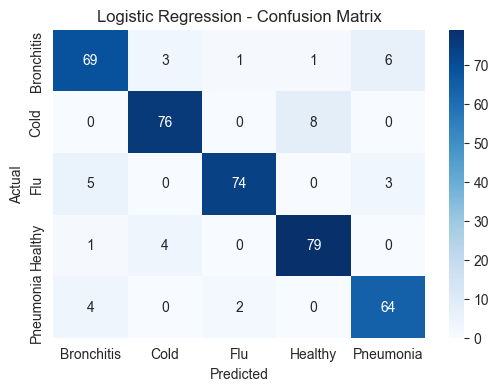


==================== Random Forest ====================
Accuracy: 0.8950

Classification Report:
              precision    recall  f1-score   support

  Bronchitis       0.87      0.86      0.87        80
        Cold       0.89      0.86      0.87        84
         Flu       0.97      0.91      0.94        82
     Healthy       0.86      0.94      0.90        84
   Pneumonia       0.89      0.90      0.89        70

    accuracy                           0.90       400
   macro avg       0.90      0.89      0.90       400
weighted avg       0.90      0.90      0.90       400



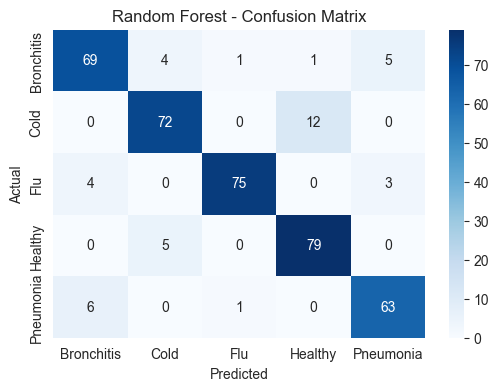


==================== LightGBM ====================
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002501 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 16
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.560648
[LightGBM] [Info] Start training from score -1.584745
[LightGBM] [Info] Start training from score -1.560648
[LightGBM] [Info] Start training from score -1.742969
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


e:\HealthCareProject\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.8700

Classification Report:
              precision    recall  f1-score   support

  Bronchitis       0.82      0.84      0.83        80
        Cold       0.86      0.86      0.86        84
         Flu       0.95      0.91      0.93        82
     Healthy       0.84      0.90      0.87        84
   Pneumonia       0.89      0.83      0.86        70

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400



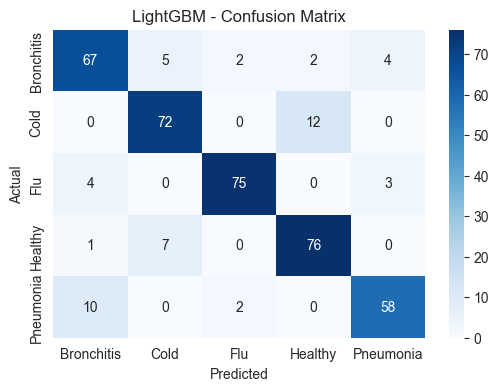

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define models with their respective preprocessors
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_lr),
        ("classifier", LogisticRegression(max_iter=500, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_rf),
        ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    "LightGBM": Pipeline([
        ("preprocessor", preprocessor_lgb),
        ("classifier", lgb.LGBMClassifier(random_state=42))
    ])
}

# Train & evaluate each model
for name, model in models.items():
    print(f"\n{'='*20} {name} {'='*20}")
    
    # Fit model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()



========== Logistic Regression Hyperparameter Tuning ==========
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

========== Random Forest Hyperparameter Tuning ==========
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

========== LightGBM Hyperparameter Tuning ==========
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000296 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 16
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start train

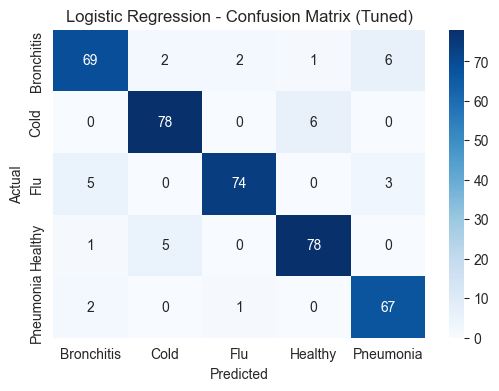


==================== Random Forest (Tuned) ====================
Accuracy: 0.8900

Classification Report:
              precision    recall  f1-score   support

  Bronchitis       0.84      0.85      0.84        80
        Cold       0.92      0.83      0.88        84
         Flu       0.95      0.91      0.93        82
     Healthy       0.85      0.98      0.91        84
   Pneumonia       0.90      0.87      0.88        70

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



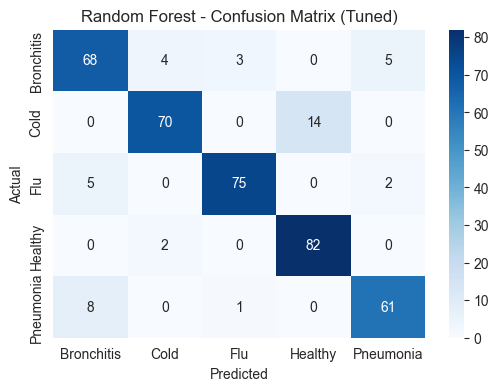


==================== LightGBM (Tuned) ====================
Accuracy: 0.8725

Classification Report:
              precision    recall  f1-score   support

  Bronchitis       0.82      0.84      0.83        80
        Cold       0.87      0.86      0.86        84
         Flu       0.95      0.93      0.94        82
     Healthy       0.85      0.92      0.88        84
   Pneumonia       0.89      0.81      0.85        70

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400



e:\HealthCareProject\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


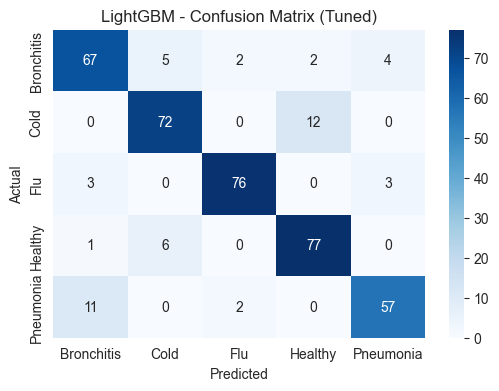

In [13]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression grid
param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"]
}

# Random Forest grid
param_grid_rf = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

# LightGBM grid
param_grid_lgb = {
    "classifier__n_estimators": [100, 200],
    "classifier__num_leaves": [31, 50],
    "classifier__learning_rate": [0.05, 0.1]
}

# Models with preprocessors
pipelines = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_lr),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_rf),
        ("classifier", RandomForestClassifier(random_state=42))
    ]),
    "LightGBM": Pipeline([
        ("preprocessor", preprocessor_lgb),
        ("classifier", lgb.LGBMClassifier(random_state=42))
    ])
}

param_grids = {
    "Logistic Regression": param_grid_lr,
    "Random Forest": param_grid_rf,
    "LightGBM": param_grid_lgb
}

best_models = {}

# Run GridSearch for each model
for name, pipeline in pipelines.items():
    print(f"\n{'='*10} {name} Hyperparameter Tuning {'='*10}")
    
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=3,
        scoring="f1_weighted",  # or "accuracy"
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)
    
    print("Best Params:", grid.best_params_)
    best_models[name] = grid.best_estimator_

# --- Evaluation of tuned models ---
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in best_models.items():
    print(f"\n{'='*20} {name} (Tuned) {'='*20}")
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f"{name} - Confusion Matrix (Tuned)")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()


In [22]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import lightgbm as lgb

sns.set_style("whitegrid")
print("✅ Libraries imported")


✅ Libraries imported


In [23]:
# Cell 2: Load and clean dataset
file_path = "../Data/disease_diagnosis.csv"
df = pd.read_csv(file_path)
print(f"Dataset loaded: {df.shape}")

# Split Blood Pressure column
if "Blood_Pressure_mmHg" in df.columns:
    bp_split = df["Blood_Pressure_mmHg"].str.split("/", expand=True)
    df["Systolic_BP"] = pd.to_numeric(bp_split[0], errors="coerce")
    df["Diastolic_BP"] = pd.to_numeric(bp_split[1], errors="coerce")
    df.drop(columns=["Blood_Pressure_mmHg"], inplace=True)

df.info()


Dataset loaded: (2000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Heart_Rate_bpm       2000 non-null   int64  
 4   Body_Temperature_C   2000 non-null   float64
 5   Oxygen_Saturation_%  2000 non-null   float64
 6   Symptom_1            2000 non-null   object 
 7   Symptom_2            1713 non-null   object 
 8   Symptom_3            1629 non-null   object 
 9   Severity             1580 non-null   object 
 10  Treatment_Plan       1580 non-null   object 
 11  Diagnosis            2000 non-null   object 
 12  Systolic_BP          2000 non-null   int64  
 13  Diastolic_BP         2000 non-null   int64  
dtypes: float64(2), int64(5), object(7)
memory usage: 218.9+ KB


In [24]:
# Cell 3: Symptom consolidation
symptom_cols = ['Symptom_1', 'Symptom_2', 'Symptom_3']
df['All_Symptoms'] = df[symptom_cols].apply(lambda row: [s for s in row if pd.notna(s)], axis=1)

mlb = MultiLabelBinarizer()
symptom_encoded = mlb.fit_transform(df['All_Symptoms'])
symptom_df = pd.DataFrame(symptom_encoded, columns=mlb.classes_, index=df.index)

df = pd.concat([df, symptom_df], axis=1)
df.drop(columns=symptom_cols + ['All_Symptoms'], inplace=True)

print(f"Symptoms encoded into {len(mlb.classes_)} binary features")


Symptoms encoded into 8 binary features


In [17]:
# Cell 4: Feature-target split and train/test
y = df["Diagnosis"]
X = df.drop(columns=["Diagnosis", "Patient_ID", "Severity", "Treatment_Plan"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (1600, 15), Test shape: (400, 15)


In [18]:
# Cell 5: Define preprocessors
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()
symptom_cols = mlb.classes_
numeric_cols_no_symptoms = [c for c in numeric_cols if c not in symptom_cols]

# Logistic Regression & SVM (needs scaling)
preprocessor_lr = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), numeric_cols_no_symptoms),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols)
], remainder="passthrough")

# Random Forest (no scaling)
preprocessor_rf = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols_no_symptoms),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols)
], remainder="passthrough")

# LightGBM (impute only, no scaling)
preprocessor_lgb = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols_no_symptoms),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols)
], remainder="passthrough")

print("✅ Preprocessors ready")


✅ Preprocessors ready


In [19]:
# Cell 6: Define pipelines and hyperparameters
pipelines = {
    "Logistic Regression": Pipeline([("preprocessor", preprocessor_lr),
                                     ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))]),
    
    "Random Forest": Pipeline([("preprocessor", preprocessor_rf),
                               ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42))]),
    
    "LightGBM": Pipeline([("preprocessor", preprocessor_lgb),
                          ("classifier", lgb.LGBMClassifier(class_weight="balanced", random_state=42))]),
    
    "SVM": Pipeline([("preprocessor", preprocessor_lr),  # needs scaling
                     ("classifier", SVC(probability=True, class_weight="balanced", random_state=42))])
}

param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.1, 1, 10],
        "classifier__solver": ["liblinear", "lbfgs"]
    },
    "Random Forest": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [None, 10, 20],
        "classifier__min_samples_split": [2, 5]
    },
    "LightGBM": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [-1, 10, 20],
        "classifier__learning_rate": [0.01, 0.1]
    },
    "SVM": {
        "classifier__C": [0.1, 1, 10],
        "classifier__kernel": ["linear", "rbf"],
        "classifier__gamma": ["scale", "auto"]
    }
}



🔹 Training Logistic Regression...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
✅ Logistic Regression Best Params: {'classifier__C': 10, 'classifier__solver': 'lbfgs'}
Accuracy: 0.9031

Classification Report:
              precision    recall  f1-score   support

  Bronchitis       0.90      0.86      0.88        80
        Cold       0.92      0.93      0.92        84
         Flu       0.96      0.89      0.92        82
     Healthy       0.92      0.93      0.92        84
   Pneumonia       0.87      0.96      0.91        70

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



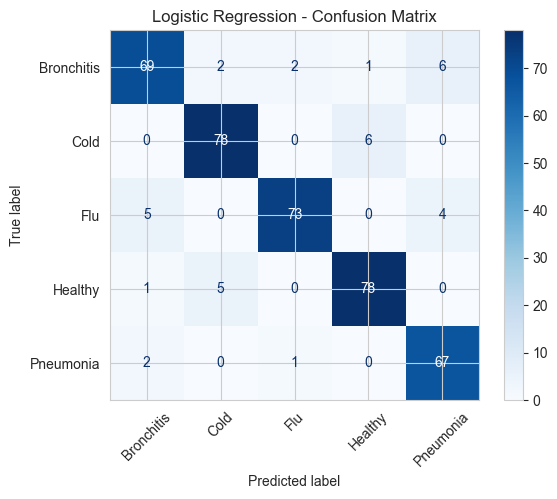


🔹 Training Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
✅ Random Forest Best Params: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Accuracy: 0.8919

Classification Report:
              precision    recall  f1-score   support

  Bronchitis       0.84      0.85      0.84        80
        Cold       0.88      0.85      0.86        84
         Flu       0.95      0.91      0.93        82
     Healthy       0.86      0.92      0.89        84
   Pneumonia       0.88      0.87      0.88        70

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



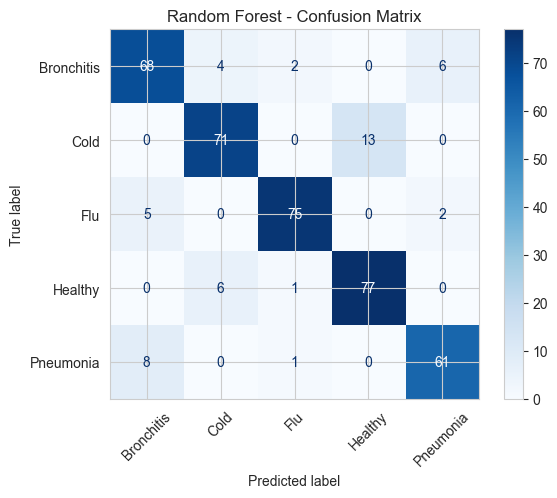


🔹 Training LightGBM...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 16
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

e:\HealthCareProject\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\HealthCareProject\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ LightGBM Best Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 10, 'classifier__n_estimators': 100}
Accuracy: 0.8800

Classification Report:
              precision    recall  f1-score   support

  Bronchitis       0.82      0.84      0.83        80
        Cold       0.85      0.86      0.85        84
         Flu       0.96      0.90      0.93        82
     Healthy       0.84      0.90      0.87        84
   Pneumonia       0.88      0.83      0.85        70

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400



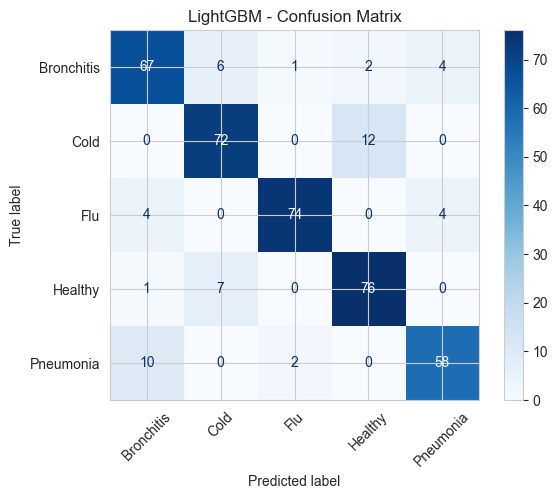


🔹 Training SVM...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
✅ SVM Best Params: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Accuracy: 0.8969

Classification Report:
              precision    recall  f1-score   support

  Bronchitis       0.87      0.84      0.85        80
        Cold       0.90      0.96      0.93        84
         Flu       0.95      0.89      0.92        82
     Healthy       0.95      0.90      0.93        84
   Pneumonia       0.84      0.91      0.88        70

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



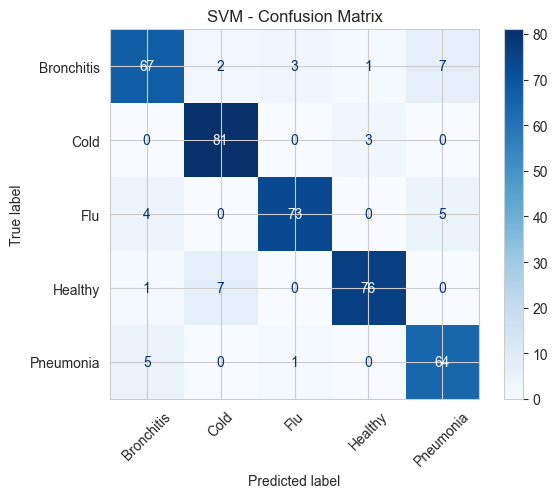

In [20]:
# Cell 7: Train with GridSearchCV and Evaluate
results = {}

for name, pipeline in pipelines.items():
    print(f"\n🔹 Training {name}...")
    grid = GridSearchCV(pipeline, param_grids[name], cv=3, scoring="accuracy", n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:,1] if hasattr(best_model["classifier"], "predict_proba") else None
    
    print(f"✅ {name} Best Params: {grid.best_params_}")
    print(f"Accuracy: {grid.best_score_:.4f}")
    
    # Save results
    results[name] = {
        "model": best_model,
        "y_pred": y_pred,
        "y_proba": y_proba
    }
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=best_model.classes_)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


In [31]:
import pandas as pd
import numpy as np

# --- Load your dataset ---
# IMPORTANT: Replace 'your_dataset.csv' with the actual path to your file.
try:
   # Cell 2: Load and clean dataset
    file_path = "../Data/disease_diagnosis.csv"
    df = pd.read_csv(file_path)
    print(f"Dataset loaded: {df.shape}")

    # --- Find and Print Unique Symptoms ---
    symptom_cols = ['Symptom_1', 'Symptom_2', 'Symptom_3']

    # 1. Stack the symptom columns into a single series
    all_symptoms_series = df[symptom_cols].stack()

    # 2. Get the unique values from that series
    unique_symptoms = all_symptoms_series.unique()

    # 3. Convert to a list and sort alphabetically
    # We also filter out any potential non-string or None values just in case
    unique_symptoms_list = sorted([str(symptom) for symptom in unique_symptoms if pd.notna(symptom)])

    print("\n-----------------------------------------")
    print("All Possible Symptoms Found in the Dataset:")
    print("-----------------------------------------")
    print(unique_symptoms_list)
    print(f"\nTotal unique symptoms: {len(unique_symptoms_list)}")
    print("\nYou can use this list to build the symptom checklist on your frontend.")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please make sure your dataset file is in the same directory or provide the full path.")





Dataset loaded: (2000, 13)

-----------------------------------------
All Possible Symptoms Found in the Dataset:
-----------------------------------------
['Body ache', 'Cough', 'Fatigue', 'Fever', 'Headache', 'Runny nose', 'Shortness of breath', 'Sore throat']

Total unique symptoms: 8

You can use this list to build the symptom checklist on your frontend.
